In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart

# --------------------------------------------------------
# 0. Setting up the environment and importing necessary libraries
# --------------------------------------------------------
# This script implements the pure sign restriction approach by Uhlig (2005) 
# to identify structural shocks in a VAR model (reproducing Fig. 6).
# Note: Ensure 'uhligdata.xls' is in the current working directory.

# ====================================================================================
# 1. DATA PREPARATION FOR THE LOCAL ENVIRONMENT
# ====================================================================================

# Load dataset and drop NA values to ensure a balanced panel.
filepath = 'uhligdata.xls'
df = pd.read_excel(filepath).dropna()

# --------------------------------------------------------
# Log-transformations
# --------------------------------------------------------
# We apply a log-transformation (* 100) to non-stationary level variables.
# Following Uhlig (2005, p. 392) and standard macroeconomic convention, the 
# federal funds rate (FEDFUNDS) is strictly EXCLUDED from this transformation, 
# as it is already expressed in percentage terms.
cols_to_log = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'BOGNONBR', 'TOTRESNS']
for col in cols_to_log:
    df[col] = np.log(df[col]) * 100

# Define the variable ordering according to the baseline model and extract the raw array.
ordered_cols = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'FEDFUNDS', 'BOGNONBR', 'TOTRESNS']
Y_raw = df[ordered_cols].values

# --------------------------------------------------------
# Constructing the VAR Design Matrix (X) and Dependent Variable (Y)
# --------------------------------------------------------
# We set the lag order p = 12 (standard for monthly macroeconomic data).
p = 12
T_raw, m = Y_raw.shape

# ENGINEERING NOTE: Dimension Management
# T is the effective sample size. We inherently lose the first p observations 
# to construct the historical lag structure.
T = T_raw - p  

# Y contains the dependent variables. By slicing [p:], we align it starting 
# strictly from the (p+1)-th observation.
Y = Y_raw[p:]

# Pre-allocate the design matrix (X) with zeros. 
# Dimensions are T (usable periods) by m*p (all lags for all variables).
X = np.zeros((T, m * p))

# ENGINEERING NOTE: Populating the Lag Matrix Block by Block
# The loop populates X iteratively for each lag 'i'. 
# - The columns: 'i*m : (i+1)*m' allocates a block of m columns for the i-th lag.
# - The rows: 'p - i - 1 : T_raw - i - 1' steps back in the Y_raw array to fetch 
#   the exact historical window for that specific lag, perfectly aligning the 
#   explanatory variables with the current period in Y.
for i in range(p):
    X[:, i*m : (i+1)*m] = Y_raw[p - i - 1 : T_raw - i - 1]

# Append a column of ones to the right side of X to account for the VAR intercept.
X = np.hstack([X, np.ones((T, 1))])

Starting Bayesian Monte Carlo simulation for pure sign restrictions...
Success! 100 / 1000 valid IRFs collected.
Success! 200 / 1000 valid IRFs collected.
Success! 300 / 1000 valid IRFs collected.
Success! 400 / 1000 valid IRFs collected.
Success! 500 / 1000 valid IRFs collected.
Success! 600 / 1000 valid IRFs collected.
Success! 700 / 1000 valid IRFs collected.
Success! 800 / 1000 valid IRFs collected.
Success! 900 / 1000 valid IRFs collected.
Success! 1000 / 1000 valid IRFs collected.

Success! 1003 posterior draws yielded 1000 valid IRFs.


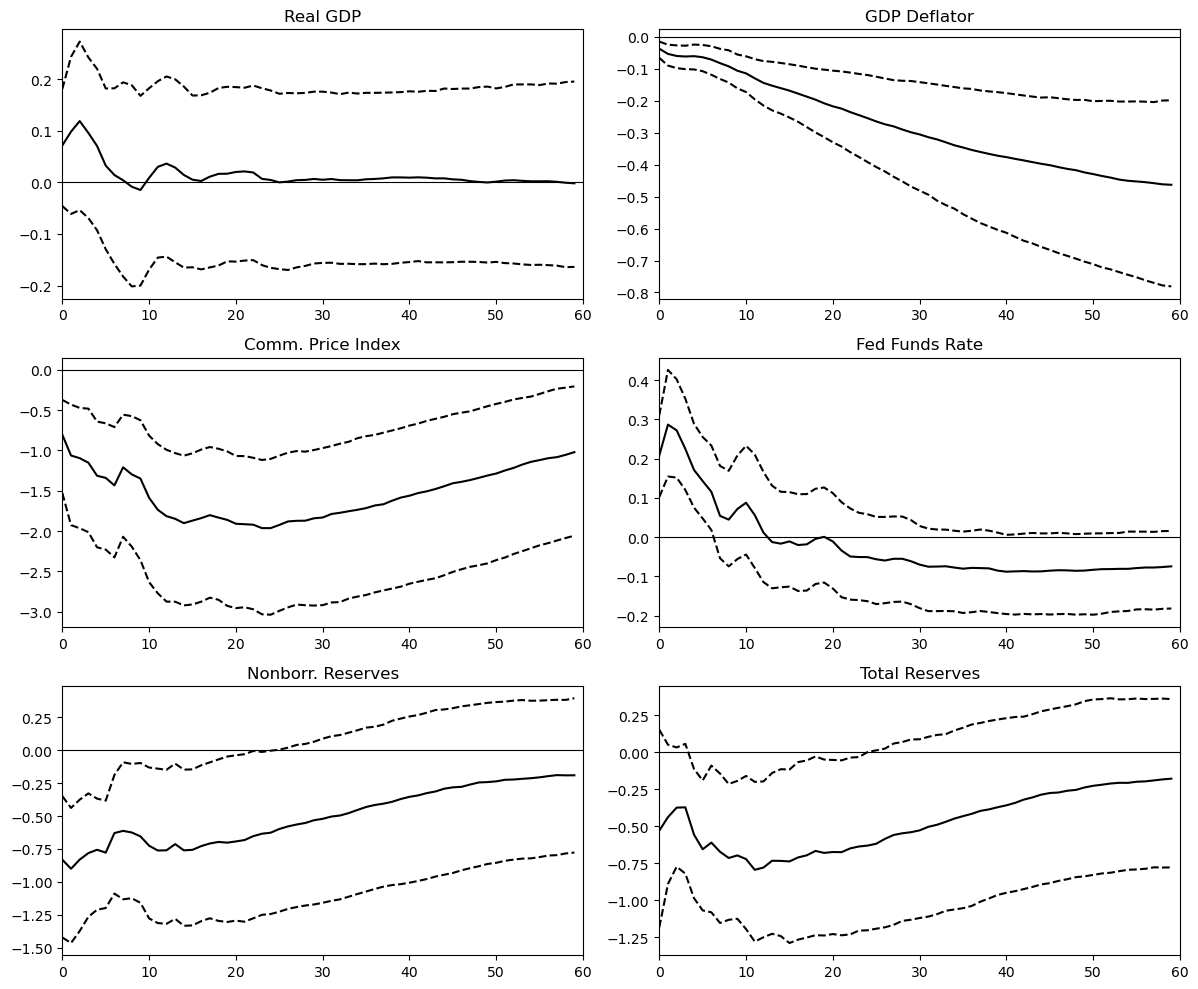

In [4]:
# ==========================================
# 2. REDUCED-FORM VAR AND POSTERIOR PARAMETERS
# ==========================================
# We estimate the reduced-form VAR (OLS) and compute the exact scale matrix 
# for the Inverse Wishart posterior distribution.

XX = X.T @ X
XX_inv = np.linalg.inv(XX)
XX_inv = (XX_inv + XX_inv.T) / 2.0  # Enforce perfect symmetry for Wishart stability

# ENGINEERING NOTE: Conjugate Prior Setup
# We rely on a Normal-Inverse Wishart prior framework. B_hat represents the posterior mean.
# S_scale is the unscaled covariance matrix of the OLS residuals, which serves as the 
# scale parameter when drawing the true covariance matrix (Omega) in the Monte Carlo loop.
B_hat = XX_inv @ X.T @ Y
U = Y - X @ B_hat

S_scale = U.T @ U
S_scale = (S_scale + S_scale.T) / 2.0


# ==========================================
# 3. BAYESIAN MONTE CARLO SIMULATION
# ==========================================
# We implement the pure sign-restriction algorithm (Uhlig, 2005). 
# For each posterior draw of the VAR parameters, we draw a random impulse vector 
# from the unit sphere and check if the resulting structural IRF satisfies the constraints.

n_keep = 1000
n_steps = 60
valid_irfs = []

print("Starting Bayesian Monte Carlo simulation for pure sign restrictions...")

# -----------------------------------------------
# 3.1. Cholesky decomposition of XX_inv
# -----------------------------------------------
# ENGINEERING NOTE: Numerical Stability
# In finite samples, XX_inv can become computationally singular. We apply a strictly 
# minimal jitter (1e-9) on the diagonal to guarantee positive-definiteness for Cholesky.
try:
    chol_XX_inv = np.linalg.cholesky(XX_inv)
except np.linalg.LinAlgError:
    chol_XX_inv = np.linalg.cholesky(XX_inv + np.eye(XX_inv.shape[0]) * 1e-9)

draw_count = 0
while len(valid_irfs) < n_keep:
    draw_count += 1
    
    # Draw the residual covariance matrix (Omega) from the Inverse Wishart distribution
    Omega_draw = invwishart.rvs(df=T, scale=S_scale)
    
    try:
        chol_Omega = np.linalg.cholesky(Omega_draw)
    except np.linalg.LinAlgError:
        chol_Omega = np.linalg.cholesky(Omega_draw + np.eye(m) * 1e-9)
    
    # -----------------------------------------------
    # 3.2. Draw from the posterior distribution of VAR coefficients (B)
    # -----------------------------------------------
    # ENGINEERING NOTE: Matrix-Normal Posterior Draw
    # To draw B, we start with the mean (B_hat) and add Gaussian noise (Z_B).
    # This noise is spatially scaled by the parameter variance (chol_XX_inv) from the left,
    # and the residual variance (chol_Omega.T) from the right.
    Z_B = np.random.randn(X.shape[1], m)
    B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Omega.T

    # ------------------------------------------------
    # 3.3. Construct the companion form and base IRFs
    # ------------------------------------------------
    # ENGINEERING NOTE: State-Space Representation
    # Calculating IRFs directly from a VAR(p) via recursive substitution is inefficient.
    # We stack the lags into a massive VAR(1) companion matrix (Gamma). 
    # The 'carry' matrix acts as memory (Gamma^k). J is a selection matrix that strictly 
    # extracts the top m x m block (the contemporaneous effects) at each iteration.
    B_ar = B_draw[:-1, :]
    Gamma = np.zeros((m * p, m * p))
    Gamma[:m, :] = B_ar.T
    Gamma[m:, :-m] = np.eye(m * (p - 1))
    
    J = np.zeros((m, m * p))
    J[:m, :m] = np.eye(m)
    
    irf_base = np.zeros((n_steps, m, m))
    carry = np.eye(m * p)
    for k in range(n_steps):
        irf_base[k] = J @ carry @ J.T @ chol_Omega
        carry = carry @ Gamma

    # ------------------------------------------------
    # 3.4. Uhlig's Unit Sphere Search & Sign Restriction Evaluation
    # ------------------------------------------------
    # ENGINEERING NOTE: Impulse Vector Generation
    # Uhlig (2005) identifies a single shock by drawing an arbitrary vector 'alpha' 
    # from the unit hypersphere. Multiplying the base IRFs by 'alpha' yields a candidate 
    # structural IRF (a specific linear combination of the reduced-form shocks).
    for _ in range(100):
        alpha = np.random.randn(m)
        alpha = alpha / np.linalg.norm(alpha)
        
        candidate_irf = irf_base @ alpha
        
        # Identification step: If the initial Fed Funds Rate response is negative, 
        # we flip the sign of the entire vector to artificially force a contractionary shock.
        if candidate_irf[0, 3] < 0:
            candidate_irf = -candidate_irf
            
        horizon = candidate_irf[:6, :]
        
        # Evaluate Uhlig's pure sign restrictions for h=0,...,5:
        # 1: GDP Deflator (<=0), 2: Comm. Price (<=0), 3: Fed Funds (>=0), 4: NBR (<=0)
        if (np.all(horizon[:, 1] <= 0) and 
            np.all(horizon[:, 2] <= 0) and 
            np.all(horizon[:, 3] >= 0) and 
            np.all(horizon[:, 4] <= 0)):
            
            valid_irfs.append(candidate_irf)
            if len(valid_irfs) % 100 == 0:
                print(f"Success! {len(valid_irfs)} / {n_keep} valid IRFs collected.", flush=True)
            break

print(f"\nSuccess! {draw_count} posterior draws yielded {n_keep} valid IRFs.")

# ==========================================
# 4. RESULTS PLOTTING
# ==========================================
valid_irfs = np.array(valid_irfs)
irf_16 = np.percentile(valid_irfs, 16, axis=0)
irf_50 = np.percentile(valid_irfs, 50, axis=0)
irf_84 = np.percentile(valid_irfs, 84, axis=0)

var_names = ['Real GDP', 'GDP Deflator', 'Comm. Price Index', 'Fed Funds Rate', 'Nonborr. Reserves', 'Total Reserves']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
x = np.arange(60)

for i in range(6):
    axes[i].plot(x, irf_50[:, i], 'k-', label='Median')
    axes[i].plot(x, irf_16[:, i], 'k--')
    axes[i].plot(x, irf_84[:, i], 'k--')
    axes[i].axhline(0, color='k', linewidth=0.8)
    axes[i].set_title(var_names[i])
    axes[i].set_xlim([0, 60])

plt.tight_layout()
plt.savefig('Uhlig_Fig6.jpg', dpi=300)
plt.show()

Starting simulation (IRFs and FEVDs)...
Success! 100 / 1000 valid IRFs collected.
Success! 200 / 1000 valid IRFs collected.
Success! 300 / 1000 valid IRFs collected.
Success! 400 / 1000 valid IRFs collected.
Success! 500 / 1000 valid IRFs collected.
Success! 600 / 1000 valid IRFs collected.
Success! 700 / 1000 valid IRFs collected.
Success! 800 / 1000 valid IRFs collected.
Success! 900 / 1000 valid IRFs collected.
Success! 1000 / 1000 valid IRFs collected.

Forecast Error Variance Decomposition (FEVD) - Median (%)
    Real GDP  GDP Deflator  Comm. Price Index  Fed Funds Rate  \
1      10.13         10.66              11.18           16.79   
10      8.62         11.46              12.55           10.93   
20      8.42         13.69              16.85            7.97   
30      8.17         14.43              20.74            8.14   
40      7.71         15.16              22.59            8.86   
50      7.49         16.35              23.17            9.46   
60      7.30         17.2

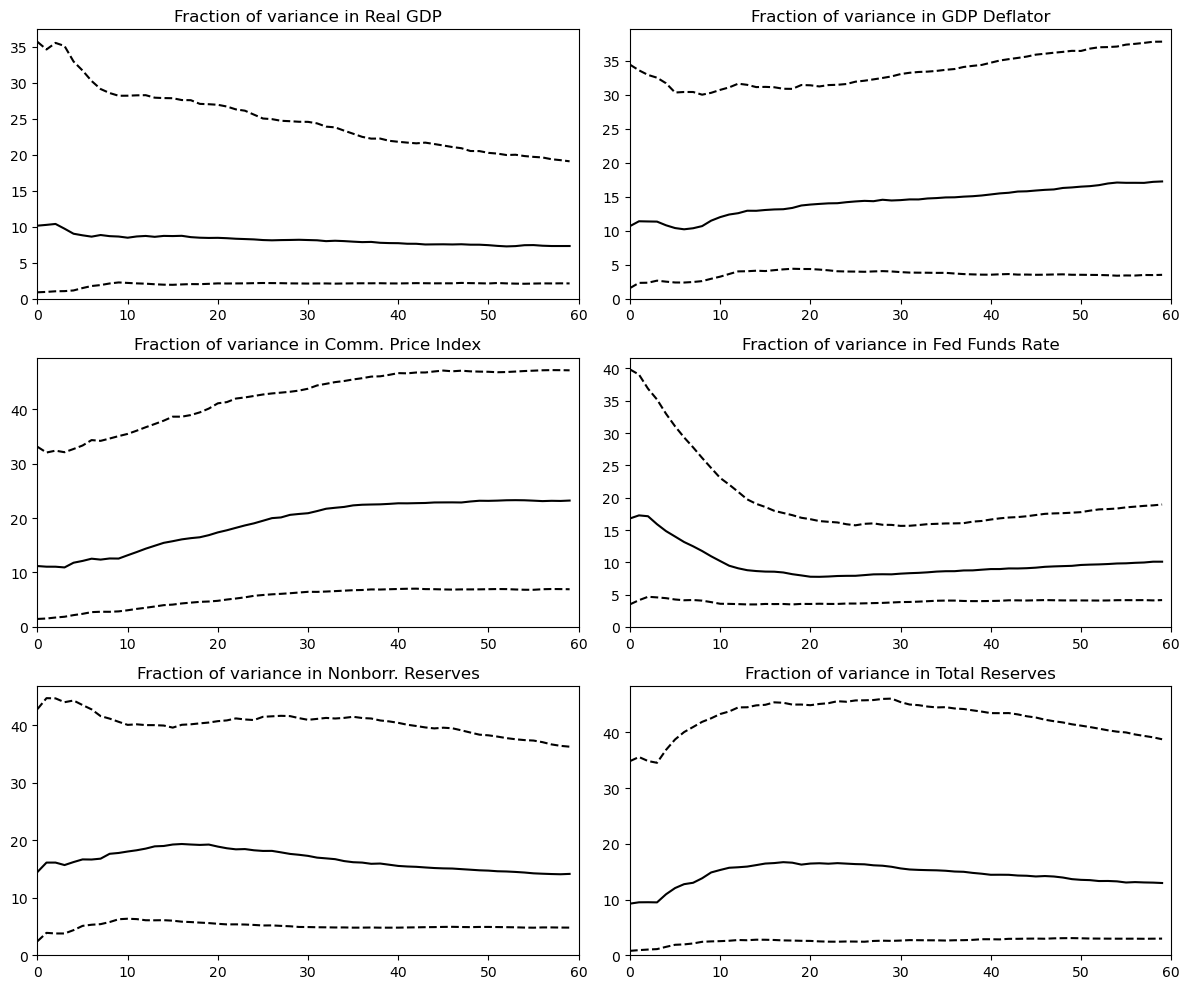

In [5]:
# ==========================================
# 3. MONTE CARLO SIMULATION (IRF and FEVD)
# ==========================================
# We estimate the posterior distribution of structural IRFs and compute the 
# Forecast Error Variance Decomposition (FEVD) for valid identification draws.

n_keep = 1000
n_steps = 60
valid_irfs = []
valid_fevds = []

print("Starting simulation (IRFs and FEVDs)...")

# Numerical stability: Cholesky of XX_inv
try:
    chol_XX_inv = np.linalg.cholesky(XX_inv)
except np.linalg.LinAlgError:
    chol_XX_inv = np.linalg.cholesky(XX_inv + np.eye(XX_inv.shape[0]) * 1e-9)

draw_count = 0
while len(valid_irfs) < n_keep:
    draw_count += 1
    
    # 3.1. Posterior draws: Inverse Wishart for Sigma, Matrix Normal for B
    Sigma_draw = invwishart.rvs(df=T, scale=S_scale)
    try:
        chol_Sigma = np.linalg.cholesky(Sigma_draw)
    except np.linalg.LinAlgError:
        chol_Sigma = np.linalg.cholesky(Sigma_draw + np.eye(m) * 1e-9)
    
    Z_B = np.random.randn(X.shape[1], m)
    B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Sigma.T
    
    # 3.2. Companion form and Base IRF computation
    B_ar = B_draw[:-1, :]
    Gamma = np.zeros((m * p, m * p))
    Gamma[:m, :] = B_ar.T
    Gamma[m:, :-m] = np.eye(m * (p - 1))
    
    J = np.zeros((m, m * p))
    J[:m, :m] = np.eye(m)
    
    irf_base = np.zeros((n_steps, m, m))
    carry = np.eye(m * p)
    for k in range(n_steps):
        irf_base[k] = J @ carry @ J.T @ chol_Sigma
        carry = carry @ Gamma
        
    # 3.3. Unit Sphere Search & Sign Restrictions
    for _ in range(100):
        alpha = np.random.randn(m)
        alpha = alpha / np.linalg.norm(alpha)
        
        candidate_irf = irf_base @ alpha
        
        # Identification: Force contractionary MP shock (flip sign if needed)
        if candidate_irf[0, 3] < 0:
            candidate_irf = -candidate_irf
            
        horizon = candidate_irf[:6, :]
        
        if (np.all(horizon[:, 1] <= 0) and 
            np.all(horizon[:, 2] <= 0) and 
            np.all(horizon[:, 3] >= 0) and 
            np.all(horizon[:, 4] <= 0)):
            
            valid_irfs.append(candidate_irf)
            
            # ENGINEERING NOTE: FEVD Calculation
            # Uhlig (2005, p. 387): The FEVD fraction is the cumulative variance 
            # attributed to the identified shock vs. total forecast error variance.
            var_identified = np.cumsum(candidate_irf**2, axis=0)
            var_total = np.cumsum(np.sum(irf_base**2, axis=2), axis=0)
            
            fevd = (var_identified / var_total) * 100
            valid_fevds.append(fevd)
            
            if len(valid_irfs) % 100 == 0:
                print(f"Success! {len(valid_irfs)} / {n_keep} valid IRFs collected.", flush=True)
            break

# ==========================================
# 4. FEVD TABLE AND FIG. 8 PLOTTING
# ==========================================
valid_fevds = np.array(valid_fevds)
fevd_50 = np.percentile(valid_fevds, 50, axis=0)
fevd_16 = np.percentile(valid_fevds, 16, axis=0)
fevd_84 = np.percentile(valid_fevds, 84, axis=0)

# Display Table
horizons = [1, 10, 20, 30, 40, 50, 60]
print("\nForecast Error Variance Decomposition (FEVD) - Median (%)")
print(pd.DataFrame(fevd_50[np.array(horizons)-1, :], columns=var_names, index=horizons).round(2))

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
x = np.arange(60)

for i in range(6):
    axes[i].plot(x, fevd_50[:, i], 'k-', label='Median')
    axes[i].plot(x, fevd_16[:, i], 'k--')
    axes[i].plot(x, fevd_84[:, i], 'k--')
    axes[i].set_ylim(bottom=0)
    axes[i].set_title(f"Fraction of variance in {var_names[i]}")
    axes[i].set_xlim([0, 60])

plt.tight_layout()
plt.savefig('Uhlig_Fig8.jpg', dpi=300)
plt.show()